# Blind Adversary — Reinforcement Learning Training (Lab 2)
PPO+LSTM solver for partial-observability Pacman-vs-Ghost.
Saves `pacman_model.pth` and `ghost_model.pth` to the current directory.

In [ ]:
CFG = {
    'train_ghost':   True,     # train GhostAgent (Hide)
    'train_pacman':  True,     # train PacmanAgent (Seek)
    'ghost_episodes':  500,    # number of episodes for Ghost
    'pacman_episodes': 500,    # number of episodes for Pacman
    'learning_rate':   3e-4,
    'max_steps':       200,     # max steps per episode
    'obs_radius':      5,       # cross-shaped vision radius
    'capture_distance': 2,      # Manhattan threshold for catch
    'checkpoint_interval': 100, # save intermediate .pth every N episodes
    'seed':            42,
    'model_dir':       '.',     # where to save .pth files
}
print('Config loaded:', CFG)

Config loaded: {'train_ghost': True, 'train_pacman': True, 'ghost_episodes': 500, 'pacman_episodes': 500, 'learning_rate': 0.0003, 'max_steps': 200, 'obs_radius': 5, 'capture_distance': 2, 'checkpoint_interval': 100, 'seed': 42, 'model_dir': '.'}


In [ ]:
import os, math, time, random, warnings
from collections import deque
from typing import Tuple, Optional, List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt
from IPython.display import clear_output

warnings.filterwarnings('ignore')

# -------- device --------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    print(f'Using device: {device}  ({gpu_name})')
    print(f'  Memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True
else:
    print(f'Using device: {device}')

# -------- reproducibility --------
SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

MODEL_DIR = CFG['model_dir']
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Model save dir: {os.path.abspath(MODEL_DIR)}')

Using device: cuda  (Tesla T4)
  Memory   : 15.6 GB
Model save dir: /kaggle/working


---
## Cell 1: Custom Gym Environment — BlindArenaEnv

In [ ]:
_UP    = (-1,  0)
_DOWN  = ( 1,  0)
_LEFT  = ( 0, -1)
_RIGHT = ( 0,  1)
_STAY  = ( 0,  0)
_DIRS  = [_UP, _DOWN, _LEFT, _RIGHT]

PACMAN_ACTION_TABLE = [
    (_UP, 1), (_DOWN, 1), (_LEFT, 1), (_RIGHT, 1),   # 0-3 : speed 1
    (_UP, 2), (_DOWN, 2), (_LEFT, 2), (_RIGHT, 2),   # 4-7 : speed 2
    (_STAY, 1),                                        # 8   : stay
]
NUM_PACMAN_ACTIONS = len(PACMAN_ACTION_TABLE)  # 9

GHOST_ACTION_LIST = [_UP, _DOWN, _LEFT, _RIGHT, _STAY]
NUM_GHOST_ACTIONS  = len(GHOST_ACTION_LIST)   # 5


class BlindArenaEnv:
    """Partial-observability arena for training RL agents (Lab 2).

    Map   : 21x21  (1=wall 0=empty -1=fog in the framework;
                    internally 1=wall 0=empty for the ground truth).
    Vision: cross-shaped rays up to `obs_radius`, walls block LOS.
    Opponent: heuristic BFS (Pacman) / flee-then-random (Ghost).
    """

    MAP_LAYOUT = [
        "#####################",
        "#.........#.........#",
        "#.###.###.#.###.###.#",
        "#...................#",
        "#.###.#.#####.#.###.#",
        "#.....#...#...#.....#",
        "#####.###.#.###.#####",
        "#...#.#.......#.#...#",
        "#####.#.#####.#.#####",
        "#.........G.........#",
        "#####.#.#####.#.#####",
        "#...#.#.......#.#...#",
        "#####.#.#####.#.#####",
        "#.........#.........#",
        "#.###.###.#.###.###.#",
        "#...#.....P.....#...#",
        "###.#.#.#####.#.#.###",
        "#.....#...#...#.....#",
        "#.#######.#.#######.#",
        "#...................#",
        "#####################",
    ]

    def __init__(
        self,
        agent_type: str = 'pacman',
        obs_radius: int = 5,
        max_steps: int = 200,
        capture_distance: int = 2,
    ):
        self.agent_type = agent_type
        self.obs_radius = obs_radius
        self.max_steps = max_steps
        self.capture_distance = capture_distance

        raw = np.array([list(r) for r in self.MAP_LAYOUT])
        self.ref_map = np.where(raw == '#', 1, 0).astype(np.int64)
        self.H, self.W = self.ref_map.shape

        self.pacman_start = (15, 10)
        self.ghost_start  = ( 9, 10)

        self.pacman_pos = None
        self.ghost_pos  = None
        self.current_step = 0
        self.explored = None

    # ----- helpers -----
    def _in_bounds(self, r: int, c: int) -> bool:
        return 0 <= r < self.H and 0 <= c < self.W

    def _get_visible_cells(self, pos):
        visible = {pos}
        r, c = pos
        for dr, dc in _DIRS:
            for d in range(1, self.obs_radius + 1):
                nr, nc = r + dr * d, c + dc * d
                if not self._in_bounds(nr, nc):
                    break
                visible.add((nr, nc))
                if self.ref_map[nr, nc] == 1:
                    break
        return visible

    def _build_observation(self, agent_type):
        """Return (3×H×W image, pos_norm) for the given agent."""
        my_pos = self.pacman_pos if agent_type == 'pacman' else self.ghost_pos
        visible = self._get_visible_cells(my_pos)

        ch_wall = np.zeros((self.H, self.W), dtype=np.float32)
        ch_seen = np.zeros((self.H, self.W), dtype=np.float32)
        ch_fog  = np.zeros((self.H, self.W), dtype=np.float32)

        for r in range(self.H):
            for c in range(self.W):
                if self.ref_map[r, c] == 1:
                    ch_wall[r, c] = 1.0
                elif (r, c) in visible:
                    ch_seen[r, c] = 1.0
                else:
                    ch_fog[r, c] = 1.0

        obs_img = np.stack([ch_wall, ch_seen, ch_fog], axis=0)
        pos_norm = np.array([my_pos[0] / self.H, my_pos[1] / self.W], dtype=np.float32)
        return obs_img, pos_norm

    def _apply_move(self, pos, move, steps=1):
        r, c = pos
        dr, dc = move
        for _ in range(steps):
            nr, nc = r + dr, c + dc
            if not self._in_bounds(nr, nc) or self.ref_map[nr, nc] == 1:
                break
            r, c = nr, nc
        return (r, c)

    # ----- heuristic opponents -----
    def _heuristic_ghost_action(self):
        """Ghost: flee visible Pacman, else random valid move."""
        ghost_visible = self._get_visible_cells(self.ghost_pos)
        if self.pacman_pos in ghost_visible:
            dr = self.ghost_pos[0] - self.pacman_pos[0]
            dc = self.ghost_pos[1] - self.pacman_pos[1]
            candidates = []
            if dr > 0: candidates.append(_DOWN)
            elif dr < 0: candidates.append(_UP)
            if dc > 0: candidates.append(_RIGHT)
            elif dc < 0: candidates.append(_LEFT)
            if not candidates:
                candidates = _DIRS
            # try each direction in order
            for move in candidates:
                nr = self.ghost_pos[0] + move[0]
                nc = self.ghost_pos[1] + move[1]
                if self._in_bounds(nr, nc) and self.ref_map[nr, nc] == 0:
                    return move
        # random valid move (copy to avoid mutating global list)
        dirs = _DIRS.copy()
        random.shuffle(dirs)
        for dr, dc in dirs:
            nr = self.ghost_pos[0] + dr
            nc = self.ghost_pos[1] + dc
            if self._in_bounds(nr, nc) and self.ref_map[nr, nc] == 0:
                return (dr, dc)
        return _STAY

    def _heuristic_pacman_action(self):
        """Pacman: BFS toward visible Ghost, else toward nearest unseen."""
        pacman_visible = self._get_visible_cells(self.pacman_pos)

        if self.ghost_pos in pacman_visible:
            target = self.ghost_pos
        else:
            unseen = []
            for r in range(self.H):
                for c in range(self.W):
                    if self.ref_map[r, c] == 0 and (r, c) not in pacman_visible:
                        unseen.append((r, c))
            if unseen:
                target = min(unseen, key=lambda p:
                             abs(p[0]-self.pacman_pos[0]) + abs(p[1]-self.pacman_pos[1]))
            else:
                target = self.ghost_pos

        q = deque()
        q.append((self.pacman_pos[0], self.pacman_pos[1], []))
        visited = {self.pacman_pos}
        while q:
            r, c, path = q.popleft()
            if (r, c) == target and path:
                return path[0]
            for dr, dc in _DIRS:
                nr, nc = r + dr, c + dc
                if self._in_bounds(nr, nc) and self.ref_map[nr, nc] == 0 and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    q.append((nr, nc, path + [(dr, dc)]))
        return _STAY

    # ----- RL interface -----
    def reset(self):
        self.pacman_pos = self.pacman_start
        self.ghost_pos  = self.ghost_start
        self.current_step = 0
        self.explored = set()
        my_pos = self.pacman_pos if self.agent_type == 'pacman' else self.ghost_pos
        self.explored.add(my_pos)
        obs, pos = self._build_observation(self.agent_type)
        return obs, pos

    def step(self, action: int):
        """Execute one step for the RL-trained agent.

        Returns:
            (obs_img, pos_norm, reward, done, info_dict)
        """
        self.current_step += 1

        if self.agent_type == 'pacman':
            move, steps = PACMAN_ACTION_TABLE[action]
            self.pacman_pos = self._apply_move(self.pacman_pos, move, steps)
            ghost_move = self._heuristic_ghost_action()
            self.ghost_pos = self._apply_move(self.ghost_pos, ghost_move, 1)
            my_pos = self.pacman_pos
        else:
            move = GHOST_ACTION_LIST[action]
            self.ghost_pos = self._apply_move(self.ghost_pos, move, 1)
            pacman_move = self._heuristic_pacman_action()
            self.pacman_pos = self._apply_move(self.pacman_pos, pacman_move, 1)
            my_pos = self.ghost_pos

        self.explored.add(my_pos)

        dist = abs(self.pacman_pos[0] - self.ghost_pos[0]) + abs(self.pacman_pos[1] - self.ghost_pos[1])
        caught = dist < self.capture_distance

        obs, pos = self._build_observation(self.agent_type)

        done = False
        reward = 0.0

        if self.agent_type == 'pacman':
            if caught:
                reward = 100.0
                done = True
            elif self.current_step >= self.max_steps:
                reward = -50.0
                done = True
            else:
                reward = -1.0
                visible = self._get_visible_cells(self.pacman_pos)
                new_cells = visible - self.explored
                reward += 0.5 * len(new_cells)
                self.explored |= visible
        else:
            if caught:
                reward = -100.0
                done = True
            elif self.current_step >= self.max_steps:
                reward = 50.0
                done = True
            else:
                reward = 1.0 + 0.2 * dist

        info = {
            'caught': caught,
            'distance': dist,
            'step': self.current_step,
            'pacman_pos': self.pacman_pos,
            'ghost_pos': self.ghost_pos,
        }
        return obs, pos, reward, done, info

---
## Cell 2: Network Architecture — Recurrent Actor-Critic (LSTM+CNN)

In [4]:
class RecurrentActorCritic(nn.Module):
    """LSTM + CNN policy for partial-observability blind adversary.

    Architecture
    -----------
    obs (3×21×21)  ──Conv2D(3→16, k=3, s=2)──Conv2D(16→32, k=3, s=2)──FC(32·6·6→128)──┐
    pos (2)        ──FC(2→16)─────────────────────────────────────────────────────────┤──concat──FC(144→128)──LSTM(128)──┬─Actor(128→n_act)
                                                                                                                      └─Critic(128→1)
    """

    def __init__(self, action_dim: int, hidden_size: int = 128):
        super().__init__()
        self.hidden_size = hidden_size

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.fc_cnn = nn.Linear(32 * 6 * 6, 128)
        self.fc_pos = nn.Linear(2, 16)
        self.fc_combine = nn.Linear(128 + 16, hidden_size)

        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)

        self.actor = nn.Linear(hidden_size, action_dim)
        self.critic = nn.Linear(hidden_size, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.orthogonal_(m.weight, gain=nn.init.calculate_gain('relu'))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def encode_obs(self, obs_img: torch.Tensor, pos: torch.Tensor) -> torch.Tensor:
        squeeze_out = (obs_img.dim() == 4)
        if squeeze_out:
            obs_img = obs_img.unsqueeze(1)
            pos = pos.unsqueeze(1)

        B, T, C, H, W = obs_img.shape
        x = obs_img.reshape(B * T, C, H, W)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.reshape(B * T, -1)
        x = F.relu(self.fc_cnn(x))

        p = pos.reshape(B * T, -1)
        p = F.relu(self.fc_pos(p))

        combined = torch.cat([x, p], dim=-1)
        combined = F.relu(self.fc_combine(combined))
        combined = combined.view(B, T, -1)

        if squeeze_out:
            combined = combined.squeeze(1)
        return combined

    def forward(self, obs_img, pos, hidden_state=None):
        squeeze_out = (obs_img.dim() == 4)
        if squeeze_out:
            obs_img = obs_img.unsqueeze(1)
            pos = pos.unsqueeze(1)

        B, T = obs_img.shape[0], obs_img.shape[1]
        features = self.encode_obs(obs_img, pos)

        if hidden_state is None:
            h = torch.zeros(1, B, self.hidden_size, device=obs_img.device)
            c = torch.zeros(1, B, self.hidden_size, device=obs_img.device)
        else:
            h, c = hidden_state

        lstm_out, (h, c) = self.lstm(features, (h, c))
        logits = self.actor(lstm_out)
        value  = self.critic(lstm_out)

        if squeeze_out:
            logits = logits.squeeze(1)
            value  = value.squeeze(1)

        return logits, value, (h, c)

    def get_action_and_value(self, obs_img, pos, hidden_state=None,
                             action=None, deterministic=False):
        logits, value, hidden_state = self.forward(obs_img, pos, hidden_state)
        probs = F.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs)

        if action is None:
            action = probs.argmax(dim=-1) if deterministic else dist.sample()

        log_prob = dist.log_prob(action)
        entropy  = dist.entropy()
        return action, log_prob, entropy, value, hidden_state


# -------- verify --------
p_net = RecurrentActorCritic(NUM_PACMAN_ACTIONS)
g_net = RecurrentActorCritic(NUM_GHOST_ACTIONS)
p_params = sum(p.numel() for p in p_net.parameters() if p.requires_grad)
g_params = sum(p.numel() for p in g_net.parameters() if p.requires_grad)
print(f'Pacman net: {p_params:,} params   |  Ghost net: {g_params:,} params')
print(f'Combined model size: {(p_params + g_params) * 4 / 1024:.1f} KB (fp32)')

Pacman net: 304,666 params   |  Ghost net: 304,150 params
Combined model size: 2378.2 KB (fp32)


---
## Cell 3: PPO Training Loop

Trains with **PPO + GAE + LSTM**.
Uses `tqdm` progress bars, checkpointing, and GPU memory logging.

In [5]:
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# -------- PPO hyperparameters --------
PPO_CFG = {
    'gamma':         0.99,
    'gae_lambda':    0.95,
    'clip_eps':      0.2,
    'vf_coef':       0.5,
    'entropy_coef':  0.01,
    'lr':            CFG['learning_rate'],
    'max_grad_norm': 0.5,
    'update_epochs': 4,
    'batch_size':    64,
}


class RolloutBuffer:
    def __init__(self):
        self.obs_imgs = []
        self.positions = []
        self.actions = []
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.dones = []

    def store(self, obs_img, pos, action, log_prob, value, reward, done):
        self.obs_imgs.append(obs_img)
        self.positions.append(pos)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.values.append(value)
        self.rewards.append(reward)
        self.dones.append(done)

    def clear(self):
        for lst in (self.obs_imgs, self.positions, self.actions,
                    self.log_probs, self.values, self.rewards, self.dones):
            lst.clear()

    def to_tensor(self, device):
        return (
            torch.stack(self.obs_imgs).to(device),
            torch.stack(self.positions).to(device),
            torch.tensor(self.actions, device=device),
            torch.tensor(self.log_probs, device=device),
            torch.tensor(self.values,  device=device, dtype=torch.float32),
            torch.tensor(self.rewards, device=device, dtype=torch.float32),
            torch.tensor(self.dones,   device=device, dtype=torch.float32),
        )


def compute_gae(rewards, values, dones, gamma, lam):
    advantages = []
    gae = 0.0
    for t in reversed(range(len(rewards))):
        next_val = 0.0 if (t == len(rewards) - 1 or dones[t]) else values[t + 1]
        delta = rewards[t] + gamma * next_val - values[t]
        gae = delta + gamma * lam * (1.0 - dones[t]) * gae
        advantages.insert(0, gae)
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns


def train_agent(agent_type: str, num_episodes: int,
                ckpt_interval: int = 100) -> tuple:
    """Train one agent with PPO+LSTM. Returns (model, histories)."""
    n_actions = NUM_PACMAN_ACTIONS if agent_type == 'pacman' else NUM_GHOST_ACTIONS
    env = BlindArenaEnv(agent_type=agent_type,
                        obs_radius=CFG['obs_radius'],
                        max_steps=CFG['max_steps'],
                        capture_distance=CFG['capture_distance'])
    model = RecurrentActorCritic(n_actions).to(device)
    optimizer = optim.Adam(model.parameters(), lr=PPO_CFG['lr'], eps=1e-5)

    pbar = tqdm(range(1, num_episodes + 1),
                desc=f'Training {agent_type.capitalize():6s}',
                unit='ep')

    best_reward = -1e9
    reward_history = []
    steps_history = []
    caught_history = []

    for episode in pbar:
        obs_img, pos = env.reset()
        obs_img = torch.from_numpy(obs_img).unsqueeze(0).to(device, non_blocking=True)
        pos = torch.from_numpy(pos).unsqueeze(0).to(device, non_blocking=True)

        hidden_state = None
        episode_reward = 0.0
        buffer = RolloutBuffer()

        for _ in range(CFG['max_steps']):
            with torch.no_grad():
                action, log_prob, _, value, hidden_state = \
                    model.get_action_and_value(obs_img, pos, hidden_state)

            next_obs, next_pos, reward, done, info = env.step(action.item())
            next_obs = torch.from_numpy(next_obs).unsqueeze(0).to(device, non_blocking=True)
            next_pos = torch.from_numpy(next_pos).unsqueeze(0).to(device, non_blocking=True)

            buffer.store(obs_img.squeeze(0), pos.squeeze(0),
                         action.item(), log_prob.item(),
                         value.item(), reward, done)

            obs_img, pos = next_obs, next_pos
            episode_reward += reward

            if done:
                break

        # ----- PPO update -----
        obs_b, pos_b, act_b, old_logp_b, val_b, rew_b, don_b = \
            buffer.to_tensor(device)
        advantages, returns = compute_gae(
            rew_b.tolist(), val_b.tolist(), don_b.tolist(),
            PPO_CFG['gamma'], PPO_CFG['gae_lambda'])
        advantages = torch.tensor(advantages, device=device, dtype=torch.float32)
        returns    = torch.tensor(returns,    device=device, dtype=torch.float32)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        T = len(rew_b)
        for _ in range(PPO_CFG['update_epochs']):
            indices = np.arange(T)
            np.random.shuffle(indices)
            for start in range(0, T, PPO_CFG['batch_size']):
                idx = sorted(indices[start:start + PPO_CFG['batch_size']])

                batch_obs = obs_b[idx].unsqueeze(0)
                batch_pos = pos_b[idx].unsqueeze(0)
                h = torch.zeros(1, 1, model.hidden_size, device=device)
                c = torch.zeros(1, 1, model.hidden_size, device=device)

                _, new_logp, entropy, new_val, _ = \
                    model.get_action_and_value(
                        batch_obs, batch_pos, (h, c), action=act_b[idx])
                new_logp = new_logp.squeeze(0)
                new_val  = new_val.squeeze(0).squeeze(-1)
                entropy  = entropy.squeeze(0)

                ratio = torch.exp(new_logp - old_logp_b[idx])
                adv   = advantages[idx]
                surr1 = ratio * adv
                surr2 = torch.clamp(ratio, 1.0 - PPO_CFG['clip_eps'],
                                    1.0 + PPO_CFG['clip_eps']) * adv
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss  = F.mse_loss(new_val, returns[idx])
                entropy_loss = -entropy.mean()

                loss = (policy_loss
                        + PPO_CFG['vf_coef'] * value_loss
                        + PPO_CFG['entropy_coef'] * entropy_loss)

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), PPO_CFG['max_grad_norm'])
                optimizer.step()

        # ----- logging -----
        reward_history.append(episode_reward)
        steps_history.append(env.current_step)
        caught_history.append(1 if info.get('caught') else 0)

        # update progress bar
        win = min(100, episode)
        avg_r = np.mean(reward_history[-win:])
        pbar.set_postfix({
            'Reward': f'{avg_r:+.1f}',
            'Steps':  f'{np.mean(steps_history[-win:]):.0f}',
            'Catch%': f'{np.mean(caught_history[-win:]):.0%}',
        })

        # ----- checkpoint -----
        if episode % ckpt_interval == 0:
            ckpt_path = os.path.join(MODEL_DIR, f'{agent_type}_model_ep{episode}.pth')
            torch.save(model.state_dict(), ckpt_path)

        # track best model
        if episode_reward > best_reward:
            best_reward = episode_reward

    # save final
    final_path = os.path.join(MODEL_DIR, f'{agent_type}_model.pth')
    torch.save(model.state_dict(), final_path)
    print(f'[{agent_type.upper()}] Final model saved: {final_path}')
    print(f'[{agent_type.upper()}] Best episode reward: {best_reward:.1f}')

    return model, reward_history, steps_history, caught_history


# ============================================================
#  LAUNCH TRAINING
# ============================================================
results = {}

if CFG['train_ghost']:
    print('=' * 60)
    print('Phase 1/2: Training GhostAgent (Hide) vs Heuristic Pacman')
    print('=' * 60)
    ghost_model, g_rew, g_steps, g_caught = train_agent(
        'ghost', CFG['ghost_episodes'], CFG['checkpoint_interval'])
    results['ghost'] = (g_rew, g_steps, g_caught)
    del ghost_model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    print()

if CFG['train_pacman']:
    print('=' * 60)
    print('Phase 2/2: Training PacmanAgent (Seek) vs Heuristic Ghost')
    print('=' * 60)
    pacman_model, p_rew, p_steps, p_caught = train_agent(
        'pacman', CFG['pacman_episodes'], CFG['checkpoint_interval'])
    results['pacman'] = (p_rew, p_steps, p_caught)
    del pacman_model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

print('\nTraining complete.')
print('Model files:')
for f in ('pacman_model.pth', 'ghost_model.pth'):
    path = os.path.join(MODEL_DIR, f)
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f'  {f}  ({size_kb:.1f} KB)')

Phase 1/2: Training GhostAgent (Hide) vs Heuristic Pacman


Training Ghost :   0%|          | 0/500 [00:00<?, ?ep/s]

[GHOST] Final model saved: ./ghost_model.pth
[GHOST] Best episode reward: 1161.4

Phase 2/2: Training PacmanAgent (Seek) vs Heuristic Ghost


Training Pacman:   0%|          | 0/500 [00:00<?, ?ep/s]

[PACMAN] Final model saved: ./pacman_model.pth
[PACMAN] Best episode reward: 118.0

Training complete.
Model files:
  pacman_model.pth  (1195.9 KB)
  ghost_model.pth  (1193.9 KB)


---
## Cell 4: Visualization — Learning Curves

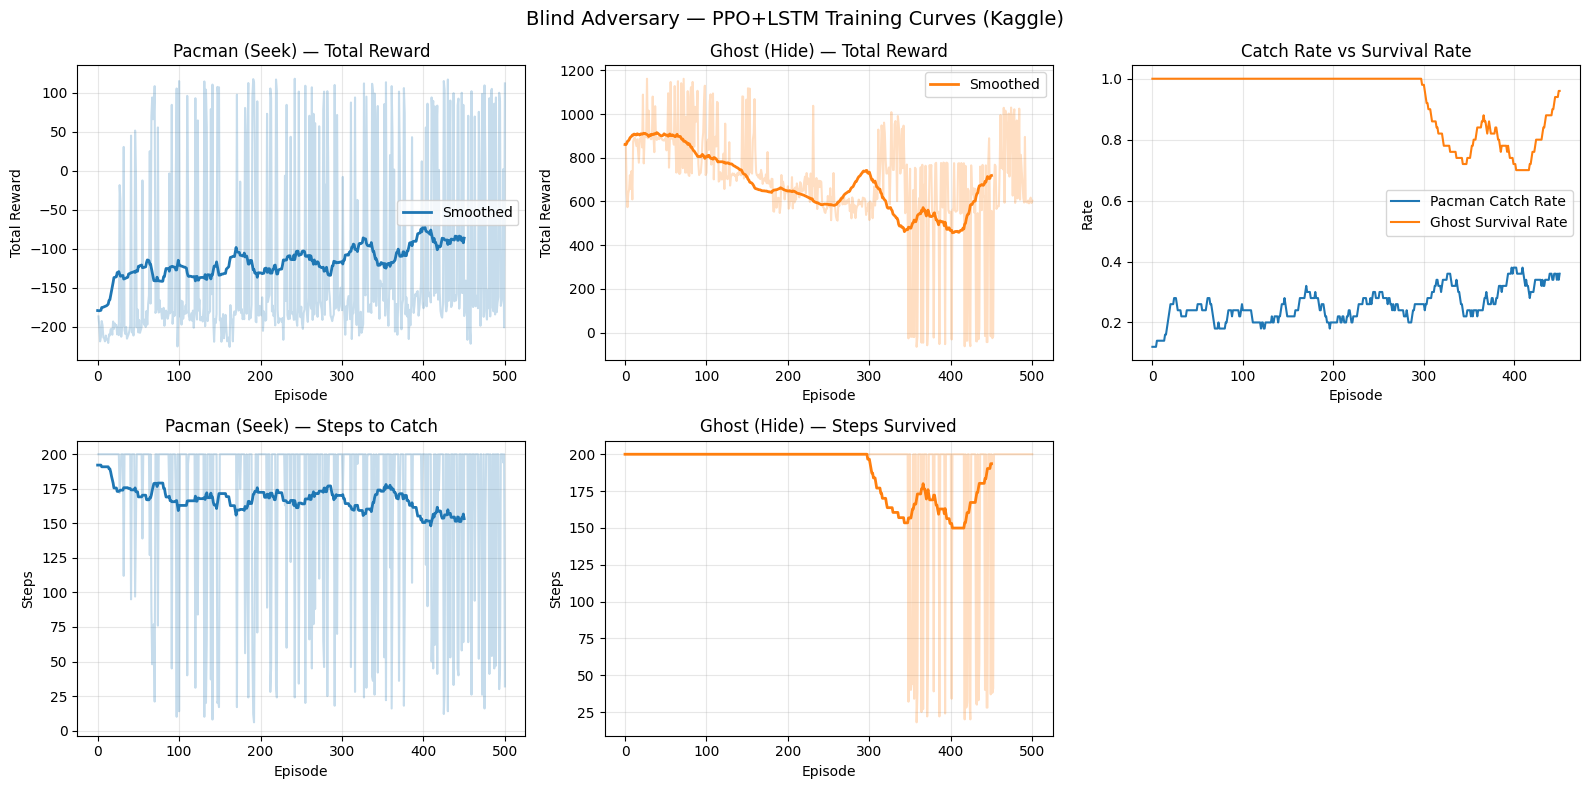

Plot saved to ./training_curves.png


In [6]:
def smooth_curve(values, window=50):
    arr = np.asarray(values, dtype=np.float64)
    if len(arr) < window:
        return arr
    cum = np.cumsum(np.insert(arr, 0, 0))
    return (cum[window:] - cum[:-window]) / window

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Blind Adversary — PPO+LSTM Training Curves (Kaggle)', fontsize=14)

entries = []
if 'pacman' in results:
    entries.append(('Pacman (Seek)', results['pacman'][0], results['pacman'][1], results['pacman'][2]))
if 'ghost' in results:
    entries.append(('Ghost (Hide)',  results['ghost'][0],  results['ghost'][1],  results['ghost'][2]))

colors = ['C0', 'C1']
for col, (name, rewards, steps, caught) in enumerate(entries):
    eps = np.arange(1, len(rewards) + 1)
    c = colors[col % 2]

    ax = axes[0, col]
    ax.plot(eps, rewards, alpha=0.25, color=c)
    ax.plot(smooth_curve(rewards), color=c, lw=2, label='Smoothed')
    ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
    ax.set_title(f'{name} — Total Reward'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    ax.plot(eps, steps, alpha=0.25, color=c)
    ax.plot(smooth_curve(steps), color=c, lw=2)
    ax.set_xlabel('Episode'); ax.set_ylabel('Steps')
    title = 'Steps to Catch' if 'Pacman' in name else 'Steps Survived'
    ax.set_title(f'{name} — {title}'); ax.grid(True, alpha=0.3)

if len(entries) >= 2:
    ax = axes[0, 2]
    ax.plot(smooth_curve(entries[0][3]), label='Pacman Catch Rate', color='C0')
    ax.plot(smooth_curve([1 - c for c in entries[1][3]]), label='Ghost Survival Rate', color='C1')
    ax.set_xlabel('Episode'); ax.set_ylabel('Rate')
    ax.set_title('Catch Rate vs Survival Rate')
    ax.legend(); ax.grid(True, alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to {os.path.join(MODEL_DIR, "training_curves.png")}')